In [1]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import StandardScaler    # Herramientas de polinomios

from sklearn.model_selection import train_test_split, KFold, cross_val_score

from formulaic import Formula

In [2]:
# Si necesitan instalar algún paquete
#!pip install gapminder
#!pip install formulaic

In [3]:
# Si necesitan cambiar de directorio de trabajo
#import os
#print(pwd)
#os.chdir('./notebooks')

# Caso de estudio: calorías de alimentos

In [4]:
df_nutricion = pd.read_csv('nutrition.csv')
df_nutricion.head()

,FDC_ID,Item,Category,Calorias_kcal,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",Baked Products,307.0,5.88,41.18,13.24,0.0,1.2,35.50,NaN,NaN
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger...",Baked Products,330.0,4.34,53.42,11.27,0.0,1.4,27.86,NaN,0.1
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...",Baked Products,377.0,6.10,79.80,3.70,NaN,NaN,3.20,NaN,NaN
3,167515,"George Weston Bakeries, Thomas English Muffins",Baked Products,232.0,8.00,46.00,1.80,NaN,NaN,42.60,NaN,NaN
4,167516,"Waffles, buttermilk, frozen, ready-to-heat",Baked Products,273.0,6.58,41.05,9.22,15.0,2.2,40.34,0.0,0.0


En este ejemplo consideramos que los datos faltantes representan que el alimento no contiene ese ingrediente y lo convertimos a 0.

In [5]:
df_nutricion.isna().sum()

FDC_ID                0
Item                  0
Category              0
Calorias_kcal         0
Proteinas_g           0
Carbohidratos_g       0
GrasaTotal_g          0
Colesterol_mg       399
Fibra_g             562
Agua_g                0
Alcohol_g          2394
VitaminaC_mg        461
dtype: int64

In [6]:
# Utilizamos fillna para convertir NaN a 0.
df_nutricion = df_nutricion.fillna(0)

In [7]:
df_nutricion.head()

,FDC_ID,Item,Category,Calorias_kcal,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
0,167512,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",Baked Products,307.0,5.88,41.18,13.24,0.0,1.2,35.50,0.0,0.0
1,167513,"Pillsbury, Cinnamon Rolls with Icing, refriger...",Baked Products,330.0,4.34,53.42,11.27,0.0,1.4,27.86,0.0,0.1
2,167514,"Kraft Foods, Shake N Bake Original Recipe, Coa...",Baked Products,377.0,6.10,79.80,3.70,0.0,0.0,3.20,0.0,0.0
3,167515,"George Weston Bakeries, Thomas English Muffins",Baked Products,232.0,8.00,46.00,1.80,0.0,0.0,42.60,0.0,0.0
4,167516,"Waffles, buttermilk, frozen, ready-to-heat",Baked Products,273.0,6.58,41.05,9.22,15.0,2.2,40.34,0.0,0.0


Construimos las matrices X e y utilizando Formulaic

In [8]:
# No usamos intercept en este modelo
y, X = (
    Formula('Calorias_kcal ~ Proteinas_g + Carbohidratos_g + GrasaTotal_g + Colesterol_mg + Fibra_g + Agua_g + Alcohol_g + VitaminaC_mg - 1')
    .get_model_matrix(df_nutricion)
)

In [9]:
X.head()

,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
0,5.88,41.18,13.24,0.0,1.2,35.50,0.0,0.0
1,4.34,53.42,11.27,0.0,1.4,27.86,0.0,0.1
2,6.10,79.80,3.70,0.0,0.0,3.20,0.0,0.0
3,8.00,46.00,1.80,0.0,0.0,42.60,0.0,0.0
4,6.58,41.05,9.22,15.0,2.2,40.34,0.0,0.0


In [10]:
y.head()

,Calorias_kcal
0,307.0
1,330.0
2,377.0
3,232.0
4,273.0


Antes de separar en entrenamiento y testeo, veamos los errores del modelo lineal con todos los datos 

In [11]:
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal. 
modelo.fit(X, y)   # Realizamos el ajuste

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Analizamos la "bondad" del ajuste.

In [12]:
y_pred = modelo.predict(X)

# Calculando el R^2
r2 = r2_score(y, y_pred)
print('R^2: ', r2)

# Calculando la RECM
ecm = mean_squared_error(y, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.9957808144789252
Raiz cuadarada del ECM:  10.960628490483586


A priori es un buen modelo, tenemos 7792 observaciones y obtenemos R^2 casi igual a 1 con solo 9 variables.

In [13]:
modelo.coef_

array([[ 4.13762244e+00,  3.97641700e+00,  8.84901423e+00,
         5.63736883e-03, -1.68542090e+00,  1.28377434e-02,
         6.85776696e+00, -2.55226271e-02]])

Vemos que las variables Proteinas_g, Carbohidratos_g, GrasaTotal_g y Alcohol_g son las que tienen coeficientes mas grandes

# Conjuntos de entrenamiento y testeo
Ajustamos el modelo separando en 80-20

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
# Construimos primero las matrices X e y utilizando Formulaic (o cualquier otro método)
y, X = (
    Formula('Calorias_kcal ~ Proteinas_g + Carbohidratos_g + GrasaTotal_g + Colesterol_mg + Fibra_g + Agua_g + Alcohol_g + VitaminaC_mg - 1')
    .get_model_matrix(df_nutricion)
)

# Separamos en entrenamiento (train) y testeo (test).
# El parámetro test_size=0.2 indica que tomamos un 20% de los datos para testeo.
# El parámetro random_state=42 es lo que se denomina semilla aleatoria. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
y_train

,Calorias_kcal
2338,45.0
6078,216.0
3541,124.0
904,228.0
1446,98.0
...,...
5226,57.0
5390,131.0
860,363.0
7603,255.0


In [17]:
X_train

,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
2338,0.00,11.27,0.00,0.0,0.0,88.45,0.0,25.0
6078,18.86,0.00,15.60,68.0,0.0,65.24,0.0,0.0
3541,17.88,1.80,4.47,262.0,0.0,74.87,0.0,16.2
904,19.60,57.90,13.70,0.0,37.0,3.00,0.0,0.0
1446,3.28,23.50,0.78,0.0,2.8,71.79,0.0,7.2
...,...,...,...,...,...,...,...,...
5226,0.22,15.32,0.07,0.0,2.0,84.13,0.0,1.0
5390,4.00,27.54,0.18,0.0,0.0,67.91,0.0,0.0
860,0.10,91.80,0.50,0.0,0.1,5.20,0.0,0.0
7603,29.20,0.00,14.50,97.0,0.0,54.30,0.0,0.0


In [18]:
X_test

,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Colesterol_mg,Fibra_g,Agua_g,Alcohol_g,VitaminaC_mg
1421,0.59,5.36,0.14,0.0,1.8,92.99,0.0,2.0
5550,5.25,81.43,1.24,0.0,0.0,9.96,0.0,61.3
5398,4.40,21.30,1.92,0.0,2.8,71.61,0.0,0.0
1025,10.00,68.26,17.93,0.0,2.5,2.30,0.0,0.0
101,7.99,55.10,6.40,0.0,3.6,28.30,0.0,0.0
...,...,...,...,...,...,...,...,...
4981,8.87,4.23,2.65,62.0,0.0,82.98,0.0,0.0
2407,0.25,0.70,0.08,0.0,0.0,98.35,0.0,0.0
4262,11.22,80.49,1.81,0.0,13.0,3.50,0.0,0.1
7367,27.68,0.00,7.01,100.0,0.0,63.92,0.0,0.0


### Números pseudo-aleatorios y semillas aleatorias.

Las computadoras no pueden generar números al azar, tienen algoritmos que generan números que parecen al azar denominados pseudo aleatorios. 

Los números se generan a partir de una semilla. Si corremos el codigo utilizando la misma semilla,  vamos a obtener siempre el mismo resultado.

Esto permite que el experimento sea reproducible.

### Entrenamiento

In [19]:
# Entrenamos el modelo utilizando los conjuntos de entrenamiento

modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal
modelo.fit(X_train, y_train)   # Realizamos el ajuste

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",False
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Testeo

In [20]:
# Medimos la bondad del ajuste en el conjunto de testeo

y_pred = modelo.predict(X_test)

# Calculando el R^2
r2 = r2_score(y_test,y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(y_test,y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.9964753848027386
Raiz cuadarada del ECM:  10.282313472084915


Vemos que el modelo ajusto bien en los datos de testeo, podemos confiar en el modelo obtenido.

**Ejercicio:** Utilizar distintas semillas aleatorias. ¿Se obtienen los mismos valores? ¿Se mantienen las conclusiones?

## Selección de modelos

Comparamos con un modelo utilizando solo las cuatro variables con mayores coeficientes y sin intercept.

In [21]:
y, X = (
    Formula('Calorias_kcal ~ Proteinas_g + Carbohidratos_g + GrasaTotal_g + Alcohol_g - 1')
    .get_model_matrix(df_nutricion)
)
X.head()

,Proteinas_g,Carbohidratos_g,GrasaTotal_g,Alcohol_g
0,5.88,41.18,13.24,0.0
1,4.34,53.42,11.27,0.0
2,6.10,79.80,3.70,0.0
3,8.00,46.00,1.80,0.0
4,6.58,41.05,9.22,0.0


In [22]:
# Separamos en entrenamiento (train) y testeo (test).
# El parámetro test_size=0.2 indica que tomamos un 20% de los datos para testeo.
# El parámetro random_state=42 es lo que se denomina semilla aleatoria. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo.fit(X_train,y_train)   # Realiza
print("Coeficientes:", modelo.coef_)

y_pred = modelo.predict(X_test)
# Calculando el R^2
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

Coeficientes: [[4.1385252  3.84562301 8.84612657 6.94384855]]
R^2:  0.9946172767699937
Raiz cuadarada del ECM:  12.70679460634204


Vemos que el modelo es un poco peor pero mucho más simple. 

**Conclusión rápida:** El modelo con 3 variables es útil para una cuenta rápida, pero si necesitamos una mayor precisión podemos utilizar el modelo completo.

**Ejercicio.** Buscar en recursos en-línea la fórmula usualmente utilizada para el cálculo de calorías y comparar con la fórmula que obtuvimos.

## Ejercicio

En el dataset de diamantes, vimos que las variables x, y y z están muy correlacionadas. Mejorará el modelo si eliminamos alguna de ellas? (variables correlacionadas pueden tener coeficientes grandes en el modelo con signos opuestos y eso aumenta los errores)

In [24]:
df_diamonds = sns.load_dataset('diamonds')
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [25]:
df_diamonds.clarity.unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, str): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [26]:
# Modelo con todas las variables numéricas
y, X = (
    Formula("price ~ carat + depth + table + x + y + z - 1")
    .get_model_matrix(df_diamonds)
)
y = y.squeeze()  # Para convertir a serie

X.head()

,carat,depth,table,x,y,z
0,0.23,61.5,55.0,3.95,3.98,2.43
1,0.21,59.8,61.0,3.89,3.84,2.31
2,0.23,56.9,65.0,4.05,4.07,2.31
3,0.29,62.4,58.0,4.20,4.23,2.63
4,0.31,63.3,58.0,4.34,4.35,2.75


In [27]:
# Separamos en entrenamiento y testeo
modelo = linear_model.LinearRegression(fit_intercept = False)   
modelo.fit(X_train,y_train)   # Realiza
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Coeficientes:", modelo.coef_)

Coeficientes: [[4.1385252  3.84562301 8.84612657 6.94384855]]


In [28]:
# Ajustamos el modelo en el conjunto de entrenamiento y calculamos los errores en el conjunto de testeo
y_pred = modelo.predict(X_test)
y_pred
# Calculando el R^2
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- carat
- depth
- table
- x
- y
- ...
Feature names seen at fit time, yet now missing:
- Alcohol_g
- Carbohidratos_g
- GrasaTotal_g
- Proteinas_g


In [ ]:
# Repetimos para el modelo sin alguna de las variables x, y o z
y,X = (
    Formula("price ~ color + cut + clarity + carat + table + x -1")
    .get_model_matrix(df_diamonds)
)

y = y.squeeze()
X.head()

,color[D],color[E],color[F],color[G],color[H],color[I],color[J],cut[T.Premium],cut[T.Very Good],cut[T.Good],...,clarity[T.VVS1],clarity[T.VVS2],clarity[T.VS1],clarity[T.VS2],clarity[T.SI1],clarity[T.SI2],clarity[T.I1],carat,table,x
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0.23,55.0,3.95
1,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0.21,61.0,3.89
2,0,1,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0.23,65.0,4.05
3,0,0,0,0,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0.29,58.0,4.20
4,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0.31,58.0,4.34


In [ ]:
# Y mejora el modelo si agregamos alguna de las variables categóricas?
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo.fit(X_train,y_train)   # Realiza
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Coeficientes:", modelo.coef_)



Coeficientes: [9498.1367881    26.36499324  -18.1964307  -537.81413438  136.19838389
 -544.50894802]


In [ ]:
# Ajustamos el modelo en el conjunto de entrenamiento y calculamos los errores en el conjunto de testeo
y_pred = modelo.predict(X_test)
y_pred
# Calculando el R^2
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.9185408744249127
Raiz cuadarada del ECM:  1137.9548210904059


# Caso de estudio: rendimiento del suelo

En una región agrícola queremos predecir el rendimiento del suelo en función del uso de distintos fertilizantes y otras variables.
Se hacen distintas mediciones y se juntan los datos en una tabla.

¿Qué variables usarían si quieren un modelo con buena capacidad predictiva y pocas variables?

Proponer un modelo para predecir el rendimiento de una hectárea cultivada en función de algunas características del lugar y los fertilizantes utilizados.

**Nota:** La variable Espigas es también una medida de rendimiento, no puede usarse como variable independiente.

In [ ]:
df_rendimiento = pd.read_csv('rendimiento.csv')
df_rendimiento

,pH,MO,P,N,S,P_Ferti,P_kgha,S_Fuente,S_kgha,Ndisp,...,Variedad,FdS,plantas,momento,IncSep,IncMam,IncRoya,FdD,Espigas,Rendimiento
0,6.2,3.1,6.0,26,4.3,MAP,100,S,0,100,...,Baguette 11,05-jun,260,Z 3.7,4.0,35.0,4.0,24-oct,621,5666
1,6.2,3.1,6.0,26,4.3,MAP,100,S,0,160,...,Baguette 11,05-jun,260,Z 3.7,4.0,35.0,4.0,24-oct,673,5874
2,6.2,3.1,6.0,26,4.3,MAP,100,S,15,160,...,Baguette 11,05-jun,249,Z 3.7,4.0,35.0,4.0,24-oct,671,5862
3,6.2,3.1,6.0,26,4.3,MAP,100,S,0,220,...,Baguette 11,05-jun,252,Z 3.7,4.0,35.0,4.0,24-oct,721,6055
4,6.2,3.1,6.0,26,4.3,MAP,140,S,0,100,...,Baguette 11,05-jun,272,Z 3.7,4.0,35.0,4.0,24-oct,656,5660
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,6.0,2.8,5.9,53,3.8,MAP,70,S,0,107,...,Guerrero,10-jun,188,Z3.9,0.0,47.0,0.0,02-nov,456,4705
152,6.0,2.8,5.9,53,3.8,MAP,100,S,0,129,...,Baguette 11,10-jun,205,Z3.9,0.0,47.0,34.0,02-nov,560,5821
153,6.0,2.8,5.9,53,3.8,MAP,70,S,0,107,...,Guerrero,10-jun,211,Z3.9,0.0,59.0,12.0,02-nov,453,5104
154,6.0,2.8,5.9,53,3.8,MAP,130,S,0,160,...,Baguette 17,10-jun,238,Z3.9,0.0,55.0,44.0,28-oct,518,4705


In [ ]:
df_rendimiento.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pH           156 non-null    float64
 1   MO           156 non-null    float64
 2   P            156 non-null    float64
 3   N            156 non-null    int64  
 4   S            156 non-null    float64
 5   P_Ferti      156 non-null    str    
 6   P_kgha       156 non-null    int64  
 7   S_Fuente     156 non-null    str    
 8   S_kgha       156 non-null    int64  
 9   Ndisp        156 non-null    int64  
 10  Palc         156 non-null    float64
 11  Variedad     156 non-null    str    
 12  FdS          156 non-null    str    
 13  plantas      156 non-null    int64  
 14  momento      156 non-null    str    
 15  IncSep       156 non-null    float64
 16  IncMam       156 non-null    float64
 17  IncRoya      156 non-null    float64
 18  FdD          156 non-null    str    
 19  Espigas      156 no

In [ ]:
# Acá están todas las variables
"Rendimiento ~ pH + MO + P + N + S + P_Ferti + P_kgha + S_Fuente + S_kgha + Ndisp + Palc + Variedad + FdS + plantas + momento + IncSep + IncMam + IncRoya"

'Rendimiento ~ pH + MO + P + N + S + P_Ferti + P_kgha + S_Fuente + S_kgha + Ndisp + Palc + Variedad + FdS + plantas + momento + IncSep + IncMam + IncRoya'

# Cuatro niveles de selección de modelos
Queremos estimar los costos de salud que tendrá un cliente de una prepaga en función de algunas variables de la persona.

In [ ]:
df_salud = pd.read_csv('insurance.csv')
df_salud

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [ ]:
df_salud.region.unique()

<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str

La variable respuesta es `charges` y el resto son variables explicativas.

**Pregunta:** ¿Cuáles son variables numércias? ¿Cuáles son categóricas? Las variables categóricas son: ¿binarias, nominales, ordinales?

In [ ]:
df_salud.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**Pregunta:** ¿Cuántas categorías tiene la variable `region`?

In [ ]:
# Otro comando útil para analizar las variables numéricas
df_salud.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Por ejemplo, en la variable `charges` vemos que el promedio es 13270, y el máximo es 63770. Esto podría indica la presencia de outliers, que dificultan el modelo. ¿Cómo podemos visualizar los outliers?

<Axes: ylabel='charges'>

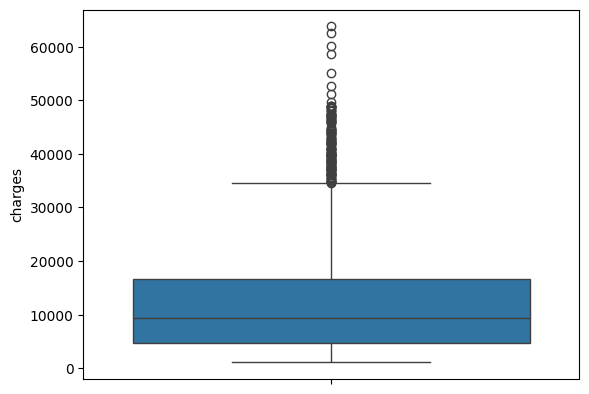

In [ ]:
sns.boxplot(df_salud.charges)

En este ejemplo dejamos los outliers. Ejercicio: ¿cambian las conclusiones si eliminamos los outliers?

## Nivel 1: entrenamos y testeamos el modelo usando todos los datos

In [ ]:
y, X = (
    Formula('charges ~ age + sex + bmi + children + smoker + region')
    .get_model_matrix(df_salud)
)
X.head()

,Intercept,age,sex[T.male],bmi,children,smoker[T.yes],region[T.northwest],region[T.southeast],region[T.southwest]
0,1.0,19,0,27.900,0,1,0,0,1
1,1.0,18,1,33.770,1,0,0,1,0
2,1.0,28,1,33.000,3,0,0,1,0
3,1.0,33,1,22.705,0,0,1,0,0
4,1.0,32,1,28.880,0,0,1,0,0


In [ ]:
# Podemos ver la correlación entre las distintas variables (corresponde al R de un modelo lineal y=ax+b)
pd.concat([X,y], axis = 1).corr()

,Intercept,age,sex[T.male],bmi,children,smoker[T.yes],region[T.northwest],region[T.southeast],region[T.southwest],charges
Intercept,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,1.000000,-0.020856,0.109272,0.042469,-0.025019,-0.000407,-0.011642,0.010016,0.299008
sex[T.male],NaN,-0.020856,1.000000,0.046371,0.017163,0.076185,-0.011156,0.017117,-0.004184,0.057292
bmi,NaN,0.109272,0.046371,1.000000,0.012759,0.003750,-0.135996,0.270025,-0.006205,0.198341
children,NaN,0.042469,0.017163,0.012759,1.000000,0.007673,0.024806,-0.023066,0.021914,0.067998
smoker[T.yes],NaN,-0.025019,0.076185,0.003750,0.007673,1.000000,-0.036945,0.068498,-0.036945,0.787251
region[T.northwest],NaN,-0.000407,-0.011156,-0.135996,0.024806,-0.036945,1.000000,-0.346265,-0.320829,-0.039905
region[T.southeast],NaN,-0.011642,0.017117,0.270025,-0.023066,0.068498,-0.346265,1.000000,-0.346265,0.073982
region[T.southwest],NaN,0.010016,-0.004184,-0.006205,0.021914,-0.036945,-0.320829,-0.346265,1.000000,-0.043210
charges,NaN,0.299008,0.057292,0.198341,0.067998,0.787251,-0.039905,0.073982,-0.043210,1.000000


In [ ]:
# Ajustamos el modelo
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo.fit(X, y)   # Realiza
print("Coeficientes:", modelo.coef_)

Coeficientes: [[-11938.53857617    256.85635254   -131.3143594     339.19345361
     475.50054515  23848.53454191   -352.96389942  -1035.02204939
    -960.0509913 ]]


In [ ]:
# Predicciones
y_pred = modelo.predict(X)

# Bondad del ajuste
r2 = r2_score(y, y_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.7509130345985207
Raiz cuadarada del ECM:  6041.6796511744515


## Nivel 2: separamos en entrenamiento y testeo

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ajustamos el modelo
modelo = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo.fit(X_train, y_train)   # Realiza

# Predicciones
y_pred = modelo.predict(X_test)

# Bondad del ajuste
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.7835929767120722
Raiz cuadarada del ECM:  5796.284659276275


**Pregunta:** Con la semilla aleatoria 42 bajó el ECM. Si cambiamos la semilla por ejemplo a 4?

## Nivel 3: separamos en entrenamiento, validación y testeo

Para crear los conjuntos podemos hacer aplicando estos pasos:
1. Separamos todo el conjunto de datos (dataframe completo) en entrenamiento y testeo.
2. A partir del dataframe de entrenamiento/validación, construimos las matrices y, X del modelo (o y1, X1 si luego vamos a comparar con otro modelo y2, X2)
3. Separamos las matrices y, X en entrenamiento y validacion (y_train, X_train, y_val, X_val)
4. Ajustamos el modelo con y_train, X_train y vemos las predicciones en y_test, X_test
5. Probamos varios modelos y elegimos el que tiene menor pérdida en validación
6. A partir del dataframe de testeo, construimos las matrices y_test, X_test con las columnas que obtuvimos en el modelo ganandor.
7. Ajustamos la fórmula en todo los datos de entrenamiento (matrices y, X) y calculamos las predicciones en testeo y las medidas de bondad del modelo elegido.

#### Paso 1: separamos en entrenamiento y testeo el dataframe original

In [ ]:
df_train, df_test = train_test_split(df_salud, test_size=0.2, random_state=42)
df_train.shape

(1070, 7)

Si realizamos alguna normalización de las variables, tenemos que tener cuidado y evitar usar en el entrenamiento datos del conjunto de testeo.

Por ejemplo, si queremos normalizar una variable mediante StandardScaler, tenemos que calcular los parámetros de la normalización en los datos de entrenamiento y aplicar esa misma transformación en los datos de testeo.

Como hacemos modelo lineal, no es importante en este caso normalizar variables (el modelo lineal es invariante por transformaciones lineales).

#### Paso 2A: definimos un primer modelo y separamos el dataset df_train en entrenamiento y validación para entrenar el modelo.

In [ ]:
formula1 = 'charges ~ age + sex + bmi + children + smoker + region'
y1, X1 = (
    Formula(formula1)
    .get_model_matrix(df_train)
)

In [ ]:
X_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X1, y1, test_size=0.2, random_state=42)
X_train.shape

(1070, 9)

In [ ]:
modelo1 = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo1.fit(X_train_1,y_train_1)   # Realizamos el ajuste

# Predicciones
y_pred = modelo1.predict(X_val_1)

# Bondad del ajuste
r2 = r2_score(y_pred,y_val_1)
print('R^2: ', r2)
ecm = mean_squared_error(y_pred,y_val_1)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.6073068097649275
Raiz cuadarada del ECM:  6602.039502172559


#### Paso 2B: definimos otro modelo y repetimos el paso 2A

In [ ]:
# Las variables sexo y región no relacionadas a los gastos
formula2 = 'charges ~ age + bmi + children + smoker'
y2, X2 = (
    Formula(formula2)
    .get_model_matrix(df_train)
)
X_train_2, X_val_2, y_train_2, y_val_2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
X_train.shape

(1070, 9)

In [ ]:
modelo2 = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
modelo2.fit(X_train_2, y_train_2)   # Realizamos el ajuste

# Predicciones
y_pred = modelo2.predict(X_val_2)

# Bondad del ajuste
r2 = r2_score(y_val_2, y_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y_val_2, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.7263709097118607
Raiz cuadarada del ECM:  6607.25812140838


De los modelos probados, nos quedamos con el de menor RECM.

#### Paso 3: analizamos como funciona el modelo en el conjunto de testeo.

**Importante:** Para esto, entrenamos el modelo ganador utilizando **TODOS** los datos de entrenamiento (el modelo es la fórmula, no los coeficientes).

**Recordar:** mientras mas datos usamos para entrenar, mejor!

In [ ]:
# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento. 
modelo1.fit(X1,y1)

# Realizamos las mismas transformaciones en el conjunto de testeo
y_test, X_test = (
    Formula(formula1)
    .get_model_matrix(df_test)
)

# Predicciones
y_pred = modelo1.predict(X_test)

# Bondad del ajuste
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.7835929767120722
Raiz cuadarada del ECM:  5796.284659276275


## Nivel 4: separamos en entrenamiento y testeo, y hacemos validación cruzada en el conjunto de entrenamiento.
### Paso 1: separamos en entrenamiento y testeo el dataframe original

In [ ]:
# La misma separación del Nivel 3
df_train, df_test = train_test_split(df_salud, test_size=0.2, random_state=42)
df_train.shape

(1070, 7)

#### Paso 2A: definimos un primer modelo y lo ajustamos por validación cruzada en el conjunto de entrenamiento.

In [ ]:
formula1 = 'charges ~ age + sex + bmi + children + smoker + region'
y1, X1 = (
    Formula(formula1)
    .get_model_matrix(df_train)
)

In [ ]:
# Definimos los subconjuntos para la validación cruzada.
# Utilizamos KFold de sklearn
cv = KFold(n_splits=5, random_state=42, shuffle=True)

## Generadores e iteradores perezosos en Python
Nos detenemos un momento para entender qué nos devuelve KFold

In [ ]:
# Esto solo nos muestra las opciones que utilizamos
cv

KFold(n_splits=5, random_state=42, shuffle=True)

In [ ]:
# La forma de utilizado es a través del método split
pliegos = cv.split(X1)
pliegos

<generator object _BaseKFold.split at 0x77bc495a5d90>

`split` nos devuelve un "generador", esto es un **iterador perezoso** (lazy iterator).

Los iteradores perezosos son objetos que se pueden recorrer como una lista. 

Sin embargo, a diferencia de las listas, los iteradores perezosos no almacenan su contenido en la memoria, lo van generando a medida que lo necesitamos.


In [ ]:
# Podemos acceder a los elementos a través de la función next
next(pliegos)

(array([   0,    1,    4,    5,    6,    7,    8,    9,   11,   13,   14,
          15,   16,   17,   18,   19,   20,   21,   22,   24,   25,   26,
          27,   28,   29,   32,   33,   34,   35,   36,   37,   38,   40,
          41,   42,   43,   44,   45,   46,   47,   48,   50,   52,   53,
          55,   56,   57,   60,   61,   62,   64,   65,   68,   69,   71,
          72,   73,   74,   75,   77,   79,   80,   81,   82,   84,   85,
          87,   89,   90,   91,   92,   93,   94,   95,   97,   98,   99,
         102,  103,  104,  105,  106,  108,  110,  111,  112,  114,  115,
         116,  117,  118,  119,  120,  121,  122,  123,  124,  125,  126,
         127,  128,  129,  130,  131,  132,  133,  134,  135,  137,  138,
         140,  142,  143,  144,  145,  146,  147,  148,  149,  150,  151,
         152,  153,  154,  155,  156,  157,  159,  160,  161,  162,  163,
         164,  165,  166,  167,  169,  170,  171,  172,  173,  175,  176,
         177,  179,  180,  181,  182, 

In [ ]:
# Pero lo mas común es utilizarlos en un ciclo:
pliegos = cv.split(X1)
for train_index, test_index in pliegos:
    print(test_index[0:10])

[ 2  3 10 12 23 30 31 39 49 51]
[ 0  5  7  9 25 29 33 43 44 55]
[ 6 11 15 18 22 24 28 41 42 46]
[ 8 16 17 19 26 36 37 38 45 48]
[ 1  4 13 14 20 21 27 32 34 35]


In [ ]:
# Ahora no quedo nada, ya generó todo lo que tenía para generar
#next(pliegos)

StopIteration: 

In [ ]:
# Acá tampoco hay nada... pero por qué no da error?
# Cómo hago para que funcione?
for train_index, test_index in pliegos:
    print(test_index[0:10])

#### Volvemos al Paso 2A

In [ ]:
# Para seleccionar algunas filas dados los índices, utilizamos iloc
for train_index, val_index in cv.split(X1):
    X_train, X_val, y_train, y_val = X1.iloc[train_index], X1.iloc[val_index], y1.iloc[train_index], y1.iloc[val_index]
    
    # Acá tenemos que hacer el ajuste y la predicción para cada pliego
    # ...

Agregamos el codigo para ajuste y predicción

In [ ]:
modelo1 = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
rmse1 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

ind = 0

# Para seleccionar algunas filas dados los índices, utilizamos iloc
for train_index, val_index in cv.split(X1):
    X_train, X_val, y_train, y_val = X1.iloc[train_index], X1.iloc[val_index], y1.iloc[train_index], y1.iloc[val_index]
    modelo1.fit(X_train, y_train)
    
    y_pred = modelo1.predict(X_val)
    rmse1[ind] = np.sqrt(mean_squared_error(y_val, y_pred))  # Guardamos los errores en un vector
    ind = ind + 1

In [ ]:
print(rmse1)

[6602.03950217 6528.25221873 5437.12516438 6427.86067043 5621.49155797]


In [ ]:
print(rmse1.mean())  # Este es el valor que queremos minimizar

6123.353822736741


#### Paso 2B: definimos otro modelo y repetimos el paso 2A

In [ ]:
formula2 = 'charges ~ age + bmi + children + region + smoker'
y2, X2 = (
    Formula(formula2)
    .get_model_matrix(df_train)
)

cv = KFold(n_splits=5, random_state=42, shuffle=True)  # No es necesario definirlo nuevamente, solo para recordar que era.

modelo2 = linear_model.LinearRegression(fit_intercept = False)    # Inicializamos un modelo de Regresion Lineal sin intercept
rmse2 = np.zeros(cv.get_n_splits())  # Vamos a guardar el error en cada pliego

ind = 0

# Para seleccionar algunas filas dados los índices, utilizamos iloc (lo vimos en la clase 2)
for train_index, test_index in cv.split(X2):
    X_train, X_val, y_train, y_val = X2.iloc[train_index], X2.iloc[val_index], y2.iloc[train_index], y2.iloc[val_index]
    modelo2.fit(X_train, y_train)
    
    y_pred = modelo2.predict(X_val)
    rmse2[ind] = np.sqrt(mean_squared_error(y_val, y_pred))
    ind = ind + 1

In [ ]:
print(rmse2)
print(rmse2.mean())  # Este es el valor que queremos minimizar

[5601.5478229  5600.54600166 5601.12884663 5593.12637971 5621.34963652]
5603.5397374833365


De los modelos probados, nos quedamos con el de menor RECM. 

#### Paso 3: analizamos como funciona el modelo en el conjunto de testeo.

Copiamos el mismo código del paso 3 del nivel 3.

In [ ]:
# Ajustamos nuestro modelo ganador en TODO el conjunto de entrenamiento. 
modelo2.fit(X2, y2)

# Realizamos las mismas transformaciones en el conjunto de testeo
y_test, X_test = (
    Formula(formula2)
    .get_model_matrix(df_test)
)

# Predicciones
y_pred = modelo2.predict(X_test)

# Bondad del ajuste
r2 = r2_score(y_test, y_pred)
print('R^2: ', r2)
ecm = mean_squared_error(y_test, y_pred)
print('Raiz cuadarada del ECM: ', np.sqrt(ecm))

R^2:  0.7835569786290855
Raiz cuadarada del ECM:  5796.766728796432


## Ejercicio: MPG

Queremos comparar dos modelos lineales para predecir la eficiencia de motores.

1. Usando todas las variables numéricas: ["displacement", "horsepower", "weight", "acceleration", "model_year", "cylinders"]
2. Usando solo las variables:  ["weight", "acceleration", "model_year"]

Usando un esquema de entrenamiento, validación y testeo,
1. ¿Cuál modelo de menores errores en entrenamiento?
2. ¿Cuál modelo de menores errores en validación?
3. ¿Con cuál de los modelos nos quedamos?
4. ¿Qué error tiene nuestro modelo en testeo?


In [ ]:
mpg = sns.load_dataset("mpg").dropna()
mpg

In [ ]:
y = mpg["mpg"]
y

**Pregunta** Contestar utilizando un esquema adecuado: ¿es conveniente agregar la variable `origin` al modelo?